### EXP 1

In [2]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,Flatten,Dense

In [3]:
c=["I like deeplearing",
  "Deep learning models can learn word embeddings",
  "word embeddings capture semantic meaning of words",
  "neural network are powerfull for NLP tasks"]
t=Tokenizer()
t.fit_on_texts(c)
w_i=t.word_index
print("vocabulary:",w_i)

vocabulary: {'word': 1, 'embeddings': 2, 'i': 3, 'like': 4, 'deeplearing': 5, 'deep': 6, 'learning': 7, 'models': 8, 'can': 9, 'learn': 10, 'capture': 11, 'semantic': 12, 'meaning': 13, 'of': 14, 'words': 15, 'neural': 16, 'network': 17, 'are': 18, 'powerfull': 19, 'for': 20, 'nlp': 21, 'tasks': 22}


In [7]:
s=t.texts_to_sequences(c)
p_s=pad_sequences(s,padding='post')
print("\nSequences\n",p_s)
print("\nPadded sequences:\n",p_s)


Sequences
 [[ 3  4  5  0  0  0  0]
 [ 6  7  8  9 10  1  2]
 [ 1  2 11 12 13 14 15]
 [16 17 18 19 20 21 22]]

Padded sequences:
 [[ 3  4  5  0  0  0  0]
 [ 6  7  8  9 10  1  2]
 [ 1  2 11 12 13 14 15]
 [16 17 18 19 20 21 22]]


In [8]:
v_s=len(w_i)+1
e_dim=8
m_len=p_s.shape[1]

In [9]:
model=Sequential([Embedding(input_dim=v_s,output_dim=e_dim,input_length=m_len),Flatten(),Dense(10,activation='relu'),Dense(1,activation='sigmoid')])

/home/ailab/anaconda3/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [10]:
model.compile(optimizer='adam',loss='binary_crossentropy')

In [11]:
labels=np.array([1,0,1,0])
model.fit(p_s,labels,epochs=20,verbose=2)

Epoch 1/20
1/1 - 1s - 521ms/step - loss: 0.6791
Epoch 2/20
1/1 - 0s - 13ms/step - loss: 0.6751
Epoch 3/20
1/1 - 0s - 12ms/step - loss: 0.6711
Epoch 4/20
1/1 - 0s - 14ms/step - loss: 0.6671
Epoch 5/20
1/1 - 0s - 13ms/step - loss: 0.6632
Epoch 6/20
1/1 - 0s - 13ms/step - loss: 0.6597
Epoch 7/20
1/1 - 0s - 14ms/step - loss: 0.6563
Epoch 8/20
1/1 - 0s - 14ms/step - loss: 0.6529
Epoch 9/20
1/1 - 0s - 12ms/step - loss: 0.6497
Epoch 10/20
1/1 - 0s - 12ms/step - loss: 0.6465
Epoch 11/20
1/1 - 0s - 14ms/step - loss: 0.6432
Epoch 12/20
1/1 - 0s - 13ms/step - loss: 0.6398
Epoch 13/20
1/1 - 0s - 13ms/step - loss: 0.6363
Epoch 14/20
1/1 - 0s - 14ms/step - loss: 0.6328
Epoch 15/20
1/1 - 0s - 13ms/step - loss: 0.6293
Epoch 16/20
1/1 - 0s - 12ms/step - loss: 0.6257
Epoch 17/20
1/1 - 0s - 13ms/step - loss: 0.6221
Epoch 18/20
1/1 - 0s - 14ms/step - loss: 0.6183
Epoch 19/20
1/1 - 0s - 13ms/step - loss: 0.6145
Epoch 20/20
1/1 - 0s - 13ms/step - loss: 0.6106


In [12]:
em=model.layers[0].get_weights()[0]
print("\n word embeddings shape:",em.shape)


 word embeddings shape: (23, 8)


In [13]:
word="deep"
word_id=w_i[word]
print(f"Embedding for word'{word}':\n",em[word_id])

Embedding for word'deep':
 [ 0.02603764  0.03966664  0.04310608 -0.03815857 -0.01428638 -0.03475918
  0.00075923 -0.0349608 ]


In [14]:
word="learning"
word_id=w_i[word]
print(f"Embedding for word'{word}':\n",em[word_id])

Embedding for word'learning':
 [-0.0341787  -0.01803588 -0.02814111 -0.00525156  0.02283334  0.03009059
  0.03960098 -0.02334848]


### EXP 2

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import AdamW

In [107]:
x,y=make_moons(n_samples=500,noise=0.2,random_state=42)

In [108]:
print("Shape of x:",x.shape)
print("Shape of y:",y.shape)
print("First 5 samples of x:\n",x[:5])
print("First 5 samples of y:\n",y[:5])

Shape of x: (500, 2)
Shape of y: (500,)
First 5 samples of x:
 [[ 0.83085779 -0.33434228]
 [ 0.99170955  0.87899966]
 [ 1.1072453  -0.47034376]
 [-0.14089918  1.03314844]
 [ 0.40559217  1.32852876]]
First 5 samples of y:
 [1 0 1 0 0]


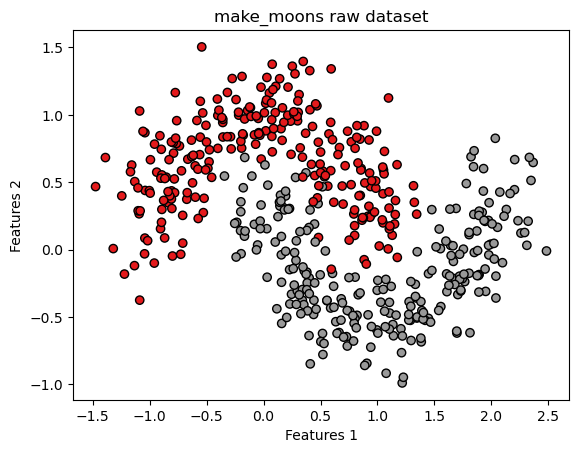

In [109]:
plt.scatter(x[:,0],x[:,1],c=y,cmap=plt.cm.Set1,edgecolor="k")
plt.title("make_moons raw dataset")
plt.xlabel("Features 1")
plt.ylabel("Features 2")
plt.show()

In [184]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scalar=StandardScaler()
x_train=scalar.fit_transform(x_train)
x_test=scalar.transform(x_test)

In [185]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(2,)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

/home/ailab/anaconda3/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [186]:
model.compile(
    optimizer='adamW',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [187]:
history=model.fit(x_train,y_train,epochs=50,batch_size=32,verbose=0)
train_loss,train_acc=model.evaluate(x_train,y_train,verbose=0)
test_loss,test_acc=model.evaluate(x_test,y_test,verbose=0)

In [188]:
print("Training accuracy:",round(train_acc,3))
print("Testing accuracy:",round(test_acc,3))

Training accuracy: 0.993
Testing accuracy: 0.97


In [189]:
xx,yy=np.meshgrid(np.linspace(x[:,0].min()-0.5,x[:,0].max()+0.5,200),np.linspace(x[:,1].min()-0.5,x[:,1].max()+0.5,200))

In [190]:
z=model.predict(scalar.transform(np.c_[xx.ravel(),yy.ravel()]))

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 579us/step


In [191]:
z=(z>0.5).astype(int).reshape(xx.shape)

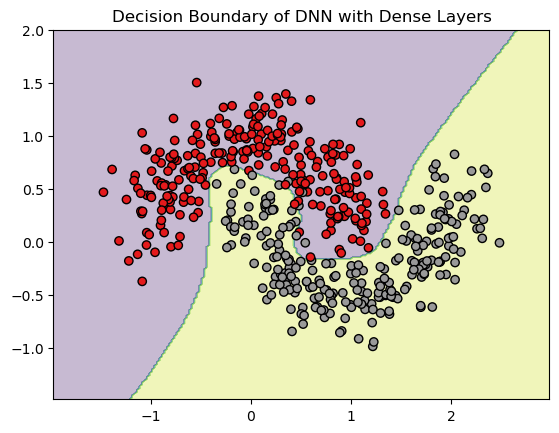

In [192]:
plt.contourf(xx,yy,z,alpha=0.3)
plt.scatter(x[:,0],x[:,1],c=y,cmap=plt.cm.Set1,edgecolor="k")
plt.title("Decision Boundary of DNN with Dense Layers")
plt.show()

### EXP 3

In [81]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import numpy as np

In [82]:
(x_train,y_train),(x_test,y_test)=datasets.mnist.load_data()

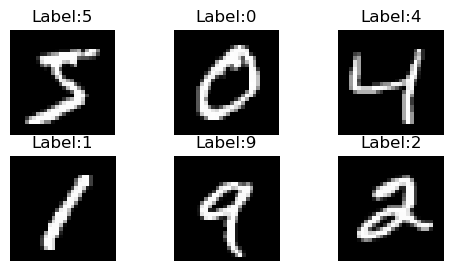

In [83]:
plt.figure(figsize=(6,3))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(x_train[i],cmap="gray")
    plt.title(f"Label:{y_train[i]}")
    plt.axis("off")
plt.show()    

In [84]:
x_train=x_train/255.0
x_test=x_test/255.0
x_train=x_train[...,np.newaxis]
x_test=x_test[...,np.newaxis]
model = models.Sequential([
    layers.Conv2D(8, (3, 3), activation='relu', input_shape=(28, 28, 1)),                          
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),                          
    layers.Dense(32, activation='relu'),                          
    layers.Dense(10, activation='softmax')                         
])

In [85]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │        43,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,706 (170.73 KB)

 Trainable params: 43,706 (170.73 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=3, validation_data=(x_test, y_test))

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8588 - loss: 0.4896 - val_accuracy: 0.9677 - val_loss: 0.1089
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9697 - loss: 0.1032 - val_accuracy: 0.9746 - val_loss: 0.0778
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9797 - loss: 0.0706 - val_accuracy: 0.9780 - val_loss: 0.0688


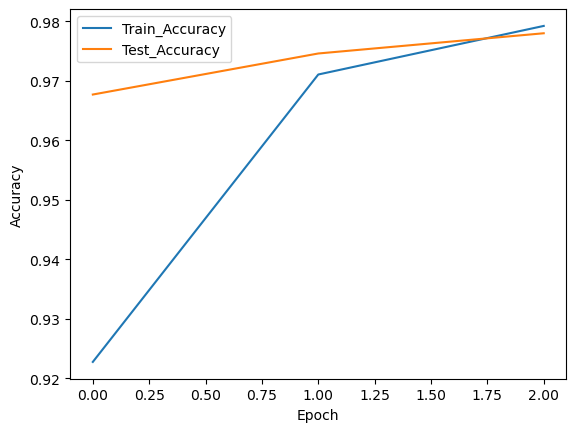

In [87]:
plt.plot(history.history['accuracy'],label='Train_Accuracy')
plt.plot(history.history['val_accuracy'],label='Test_Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

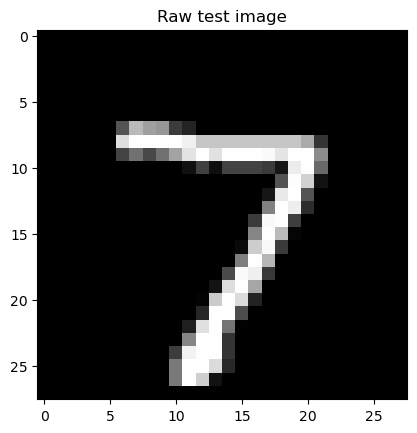

In [90]:
test_img=x_test[0]
plt.imshow(test_img.reshape(28,28),cmap="gray")
plt.title("Raw test image")
plt.show()

In [91]:
pred=model.predict(test_img[np.newaxis,...])
print("Model prediction:",np.argmax(pred))
print("True label:",y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Model prediction: 7
True label: 7


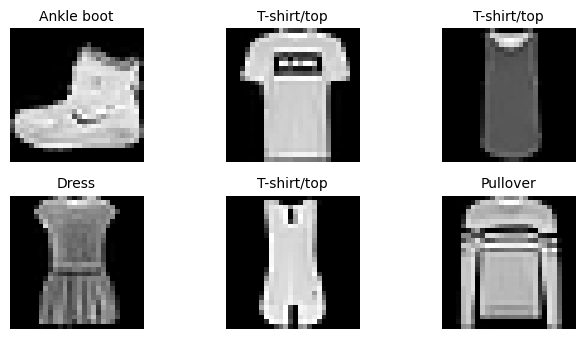

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │       173,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,930 (679.41 KB)

 Trainable params: 173,930 (679.41 KB)

 Non-trainable params: 0 (0.00 B)

In [92]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

plt.figure(figsize=(7, 3.5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis("off")
    plt.title(class_names[y_train[i]], fontsize=10)
plt.tight_layout()
plt.show()

x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') 
])
model.summary()

In [93]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=3, validation_data=(x_test, y_test))

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8048 - loss: 0.5707 - val_accuracy: 0.8756 - val_loss: 0.3515
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8968 - loss: 0.2978 - val_accuracy: 0.8934 - val_loss: 0.3051
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9091 - loss: 0.2514 - val_accuracy: 0.8980 - val_loss: 0.2819


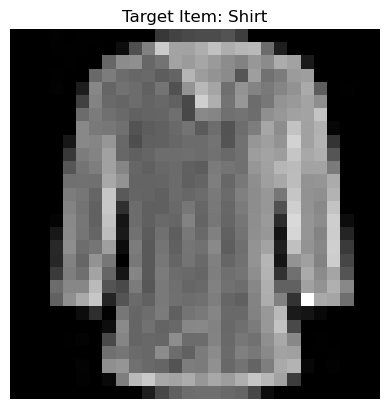

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Model Prediction: Shirt
True Label: Shirt


In [98]:
test_index = 4
test_img = x_test[test_index]

plt.imshow(test_img.reshape(28, 28), cmap="gray")
plt.axis("off")
plt.title(f"Target Item: {class_names[y_test[test_index]]}")
plt.show()

pred = model.predict(test_img[np.newaxis, ...])
predicted_class_idx = np.argmax(pred)

print("Model Prediction:", class_names[predicted_class_idx])
print("True Label:", class_names[y_test[test_index]])

### EXP 4

In [71]:
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt

In [72]:
(x_train, _),(x_test, _)=tf.keras.datasets.mnist.load_data()

In [73]:
x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0
x_train=x_train.reshape(len(x_train),784)
x_test=x_test.reshape(len(x_test),784)

In [74]:
input_img=layers.Input(shape=(784,))
encoded=layers.Dense(128,activation='relu')(input_img)
encoded=layers.Dense(64,activation='relu')(encoded)
encoded=layers.Dense(32,activation='relu')(encoded)
# encoded=layers.Dense(16,activation='relu')(encoded)
# encoded=layers.Dense(8,activation='relu')(encoded)

In [75]:
decoded=layers.Dense(64,activation='relu')(encoded)
# decoded=layers.Dense(32,activation='relu')(decoded)
# decoded=layers.Dense(64,activation='relu')(decoded)
decoded=layers.Dense(128,activation='relu')(decoded)
decoded=layers.Dense(784,activation='sigmoid')(decoded)

In [76]:
autoencoder=models.Model(input_img,decoded)

In [77]:
autoencoder.compile(optimizer='adam',loss='mse')
autoencoder.fit(x_train,x_train,epochs=5,batch_size=256,shuffle=True,validation_data=(x_test,x_test))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0976 - val_loss: 0.0381
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0343 - val_loss: 0.0262
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0255 - val_loss: 0.0222
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0219 - val_loss: 0.0197
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0196 - val_loss: 0.0181


In [78]:
decoded_img=autoencoder.predict(x_test)
n=5

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step


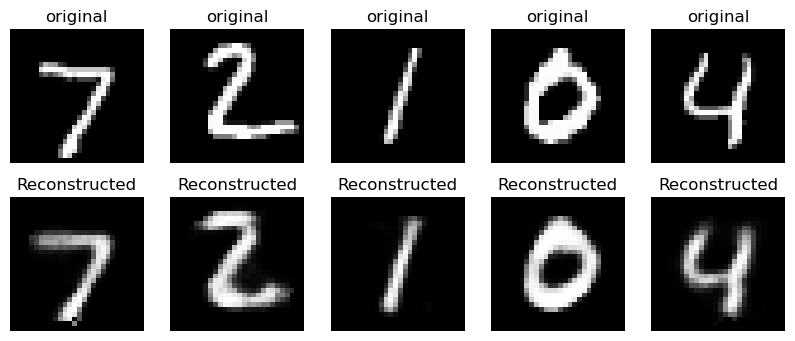

In [79]:
plt.figure(figsize=(10,4))
for i in range(n):
    ax=plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap='gray')
    plt.title("original")
    plt.axis("off")
    ax=plt.subplot(2,n,i+1+n)
    plt.imshow(decoded_img[i].reshape(28,28),cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")
plt.show()    

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0766 - val_loss: 0.0250
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0233 - val_loss: 0.0207
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0201 - val_loss: 0.0189
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0185 - val_loss: 0.0176
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0172 - val_loss: 0.0166
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 607us/step


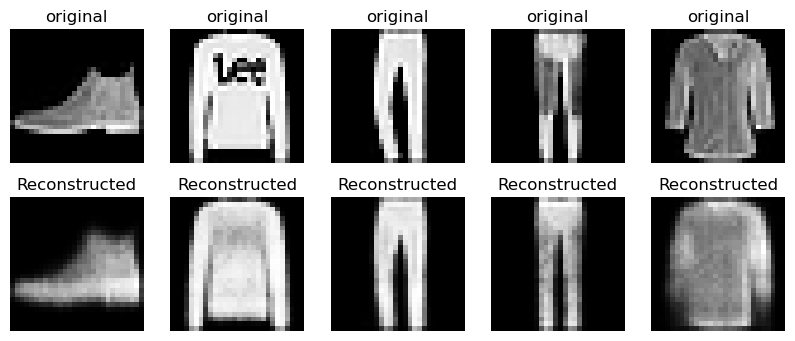

In [85]:
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt
(x_train, _),(x_test, _)=tf.keras.datasets.fashion_mnist.load_data()
x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0
x_train=x_train.reshape(len(x_train),784)
x_test=x_test.reshape(len(x_test),784)
input_img=layers.Input(shape=(784,))
encoded=layers.Dense(128,activation='relu')(input_img)
encoded=layers.Dense(64,activation='relu')(encoded)
encoded=layers.Dense(32,activation='relu')(encoded)
# encoded=layers.Dense(16,activation='relu')(encoded)
# encoded=layers.Dense(8,activation='relu')(encoded)
decoded=layers.Dense(64,activation='relu')(encoded)
# decoded=layers.Dense(32,activation='relu')(decoded)
# decoded=layers.Dense(64,activation='relu')(decoded)
decoded=layers.Dense(128,activation='relu')(decoded)
decoded=layers.Dense(784,activation='sigmoid')(decoded)
autoencoder=models.Model(input_img,decoded)
autoencoder.compile(optimizer='adam',loss='mse')
autoencoder.fit(x_train,x_train,epochs=5,batch_size=256,shuffle=True,validation_data=(x_test,x_test))
decoded_img=autoencoder.predict(x_test)
n=5
plt.figure(figsize=(10,4))
for i in range(n):
    ax=plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap='gray')
    plt.title("original")
    plt.axis("off")
    ax=plt.subplot(2,n,i+1+n)
    plt.imshow(decoded_img[i].reshape(28,28),cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")
plt.show()    

### EXP 5